# Model 2

## 1. Imports

In [1]:
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    precision_recall_curve,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

# Reproducibility 
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print('\nLibraries loaded successfully!')

Using device: cuda
  GPU: NVIDIA GeForce MX550
  VRAM: 2.1 GB

Libraries loaded successfully!


## 2. Load Preprocessed Data & Metadata

In [2]:
DATA_DIR = '../../Data/Preprocessed'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

with open(f'{DATA_DIR}/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

cat_cols   = metadata['cat_cols'] # label-encoded categoricals
num_cols   = metadata['num_cols'] # scaled numericals
vocab_sizes = metadata['vocab_sizes'] # {col: vocab_size} for embedding layers
target     = metadata['target'] # 'isFraud'

cat_cols  = [c for c in cat_cols  if c in train_df.columns]
num_cols  = [c for c in num_cols  if c in train_df.columns]

print(f'Train      : {train_df.shape}')
print(f'Validation : {val_df.shape}')
print(f'Test       : {test_df.shape}')
print(f'\nNumerical features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'\nFraud rate — Train: {train_df[target].mean():.3%} | Val: {val_df[target].mean():.3%} | Test: {test_df[target].mean():.3%}')

Train      : (472443, 469)
Validation : (29516, 469)
Test       : (88581, 469)

Numerical features  : 427
Categorical features: 41

Fraud rate — Train: 3.499% | Val: 3.500% | Test: 3.498%


## 3. PyTorch Dataset

In [3]:
class FraudDataset(Dataset):
    def __init__(self, df, num_cols, cat_cols, target):
        self.num_data = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.cat_data = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.labels   = torch.tensor(df[target].values,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.labels[idx]


# Datasets & DataLoaders 
BATCH_SIZE = 4096  
NUM_WORKERS = 0     

train_ds = FraudDataset(train_df, num_cols, cat_cols, target)
val_ds   = FraudDataset(val_df,   num_cols, cat_cols, target)
test_ds  = FraudDataset(test_df,  num_cols, cat_cols, target)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 116
Val batches   : 8
Test batches  : 22


## 4. Model Architecture

In [4]:
class FraudDNN(nn.Module):

    def __init__(self, num_numerical: int, vocab_sizes: dict,
                 hidden_dims=(512, 256, 128, 64),
                 dropout_rates=(0.3, 0.3, 0.2, 0.2)):
        super().__init__()

        # Embedding layers 
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=min(50, (vocab_size + 1) // 2)
            )
            for col, vocab_size in vocab_sizes.items()
            if col in cat_cols  # only embed columns that exist in data
        })

        total_embed_dim = sum(
            min(50, (v + 1) // 2)
            for col, v in vocab_sizes.items()
            if col in cat_cols
        )

        input_dim = num_numerical + total_embed_dim

        # MLP backbone 
        layers = []
        in_dim = input_dim
        for out_dim, drop in zip(hidden_dims, dropout_rates):
            layers.extend([
                nn.BatchNorm1d(in_dim),
                nn.Linear(in_dim, out_dim),
                nn.GELU(),
                nn.Dropout(drop)
            ])
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))  # output logit
        self.mlp = nn.Sequential(*layers)

        # Weight initialisation — He init for linear layers
        self._init_weights()

    def _init_weights(self):
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, num_feats, cat_feats):
        # cat_feats: (batch, num_cat_cols): each col's index goes to its embedding
        embed_out = []
        for i, col in enumerate(cat_cols):
            if col in self.embeddings:
                embed_out.append(self.embeddings[col](cat_feats[:, i]))

        if embed_out:
            x = torch.cat([num_feats] + embed_out, dim=1)
        else:
            x = num_feats

        return self.mlp(x).squeeze(1)  # (batch,) logits


# Instantiate 
model = FraudDNN(
    num_numerical=len(num_cols),
    vocab_sizes=vocab_sizes
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'\nModel architecture:')
print(model)

Total parameters    : 1,653,595
Trainable parameters: 1,653,595

Model architecture:
FraudDNN(
  (embeddings): ModuleDict(
    (ProductCD): Embedding(6, 3)
    (card1): Embedding(12819, 50)
    (card2): Embedding(502, 50)
    (card3): Embedding(115, 50)
    (card4): Embedding(6, 3)
    (card5): Embedding(116, 50)
    (card6): Embedding(6, 3)
    (addr1): Embedding(307, 50)
    (addr2): Embedding(71, 36)
    (P_emaildomain): Embedding(61, 31)
    (R_emaildomain): Embedding(62, 31)
    (M1): Embedding(4, 2)
    (M2): Embedding(4, 2)
    (M3): Embedding(4, 2)
    (M4): Embedding(5, 3)
    (M5): Embedding(4, 2)
    (M6): Embedding(4, 2)
    (M7): Embedding(4, 2)
    (M8): Embedding(4, 2)
    (M9): Embedding(4, 2)
    (id_12): Embedding(4, 2)
    (id_13): Embedding(55, 28)
    (id_14): Embedding(26, 13)
    (id_15): Embedding(5, 3)
    (id_16): Embedding(4, 2)
    (id_17): Embedding(103, 50)
    (id_19): Embedding(517, 50)
    (id_20): Embedding(386, 50)
    (id_28): Embedding(4, 2)
    (id

## 5. Loss, Optimiser & Scheduler

In [5]:
# Class imbalance weight 
# pos_weight = (number of negatives) / (number of positives)
# This tells BCEWithLogitsLoss to penalise missed frauds more
n_pos = train_df[target].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f'Positives (fraud)  : {int(n_pos):,}')
print(f'Negatives (legit)  : {int(n_neg):,}')
print(f'pos_weight applied : {pos_weight.item():.2f}x')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimiser 
# Adam with mild weight decay for L2 regularisation
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

# Learning rate scheduler 
# CosineAnnealingLR: smoothly decays LR from lr → eta_min over T_max epochs
# This helps the model settle into flatter minima in later epochs
NUM_EPOCHS = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f'\nOptimiser : Adam (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS}, eta_min=1e-6)')
print(f'Epochs    : {NUM_EPOCHS}')

Positives (fraud)  : 16,531
Negatives (legit)  : 455,912
pos_weight applied : 27.58x

Optimiser : Adam (lr=0.001, wd=0.0001)
Scheduler : CosineAnnealingLR (T_max=30, eta_min=1e-6)
Epochs    : 30


## 6. Output Directory

In [6]:
# Output directory (mirrors base_code convention) 
import datetime, json as _json

RUN_NAME = "DNN (GELU, 4-Layer, Embeddings)"  # change as needed
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join("Model_outputs", "Model_2")
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run name : {RUN_NAME}")
print(f"Output   : {RUN_DIR}")

Run name : DNN (GELU, 4-Layer, Embeddings)
Output   : Model_outputs\Model_2


## 7. Helper Functions

In [7]:
# Helper functions

def train_epoch(model, loader, optimizer, criterion):
    """Run one training epoch; returns average loss."""
    model.train()
    total_loss = 0
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        y         = y.to(device)
        optimizer.zero_grad()
        logits = model(num_feats, cat_feats)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_metrics(model, loader):
    """Returns PR-AUC (Average Precision) on the given loader."""
    model.eval()
    all_proba, all_y = [], []
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        logits    = model(num_feats, cat_feats)
        proba     = torch.sigmoid(logits).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return average_precision_score(np.array(all_y), np.array(all_proba))


@torch.no_grad()
def get_predictions(model, loader):
    """Returns (y_true, y_proba) arrays for the given loader."""
    model.eval()
    all_proba, all_y = [], []
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        logits    = model(num_feats, cat_feats)
        proba     = torch.sigmoid(logits).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_proba)


def plot_confusion_matrix(y_true, y_proba, threshold=0.5, title="Test Set", save_dir='.'):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[0].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nCounts')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[1].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nRow-normalised')

    plt.tight_layout()
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150)
    plt.show()

    print(f"\nClassification Report (threshold={threshold:.3f}):")
    report = classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud'])
    print(report)
    with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
        f.write(f"Threshold: {threshold:.3f}\n\n")
        f.write(report)
    print(f"Confusion matrix saved to {cm_path}")

## 8. Training

In [8]:
N_EPOCHS_FULL = NUM_EPOCHS   

print(f"\n{'='*60}")
print(f"Full training for {N_EPOCHS_FULL} epochs")
print(f"{'='*60}\n")

history         = {'train_loss': [], 'val_pr': []}
best_state      = None
best_val_pr_auc = 0

print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

epoch_log_rows = []
for epoch in range(1, N_EPOCHS_FULL + 1):
    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_pr     = evaluate_metrics(model, val_loader)
    scheduler.step()
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_pr'].append(val_pr)

    if val_pr > best_val_pr_auc:
        best_val_pr_auc = val_pr
        best_state      = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"  {epoch:>6}/{N_EPOCHS_FULL}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
    epoch_log_rows.append({'epoch': epoch, 'train_loss': train_loss,
                           'val_pr': val_pr, 'time_s': round(elapsed, 1)})

pd.DataFrame(epoch_log_rows).to_csv(os.path.join(RUN_DIR, 'training_log.csv'), index=False)


Full training for 30 epochs

   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/30    0.9726      0.4990    49.2s
       2/30    0.7869      0.5544    48.1s
       3/30    0.6936      0.6115    70.4s
       4/30    0.6231      0.6426    52.9s
       5/30    0.5662      0.6629    51.0s
       6/30    0.5191      0.6928    55.3s
       7/30    0.4738      0.7109    55.2s
       8/30    0.4455      0.7146    50.4s
       9/30    0.4032      0.7449    51.7s
      10/30    0.3809      0.7515    50.5s
      11/30    0.3561      0.7622    48.8s
      12/30    0.3317      0.7609    51.4s
      13/30    0.3110      0.7754    51.8s
      14/30    0.2829      0.7813    50.0s
      15/30    0.2742      0.7882    49.0s
      16/30    0.2556      0.7963    50.3s
      17/30    0.2376      0.7939    50.0s
      18/30    0.2251      0.8000    50.6s
      19/30    0.2136      0.8006    50.2s
      20/30    0.1990      0.8021    53.6s
      21/30    0.1847      0.8

## 9. Evaluation

In [9]:
model.load_state_dict(best_state)
val_pr  = evaluate_metrics(model, val_loader)
test_pr = evaluate_metrics(model, test_loader)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.8108
  Test PR-AUC : 0.8148


## 10. Plots

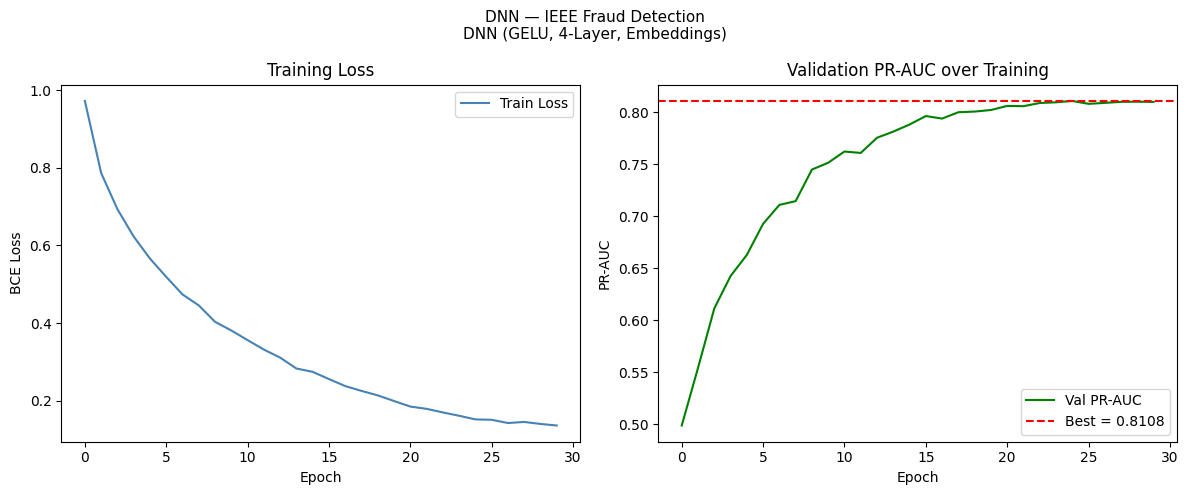

Training curves saved to Model_outputs\Model_2\dnn_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training Loss')
ax.legend()

ax = axes[1]
ax.plot(history['val_pr'], label='Val PR-AUC', color='green')
ax.axhline(y=best_val_pr_auc, color='red', linestyle='--', label=f'Best = {best_val_pr_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('PR-AUC')
ax.set_title('Validation PR-AUC over Training')
ax.legend()

plt.suptitle(f'DNN — IEEE Fraud Detection\n{RUN_NAME}', fontsize=11)
plt.tight_layout()
curves_path = os.path.join(RUN_DIR, 'dnn_training_curves.png')
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Training curves saved to {curves_path}")

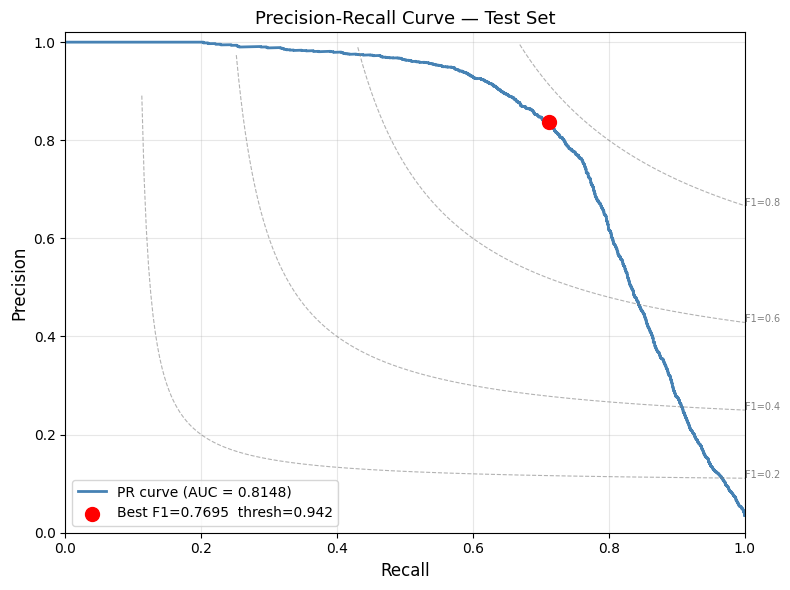

PR curve saved to Model_outputs\Model_2\pr_curve.png


In [11]:
## PR Curve + best threshold based on F1

y_true, y_proba = get_predictions(model, test_loader)

precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

# F1 at every threshold 
f1_scores   = (2 * precision_pts[:-1] * recall_pts[:-1]
               / (precision_pts[:-1] + recall_pts[:-1] + 1e-8))
best_idx    = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores[best_idx])

# Recall and precision at the best-F1 threshold
best_recall    = float(recall_pts[best_idx])
best_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr:.4f})')
ax.scatter(best_recall, best_precision, color='red', zorder=5, s=100,
           label=f'Best F1={best_f1:.4f}  thresh={best_thresh:.3f}')

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
pr_curve_path = os.path.join(RUN_DIR, 'pr_curve.png')
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

In [12]:
val_y_true, val_proba = get_predictions(model, val_loader)
val_recall  = recall_score(val_y_true,
                           (val_proba  >= best_thresh).astype(int),
                           zero_division=0)
test_recall = best_recall   # already computed above from PR curve

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC  : {test_pr:.4f}")
print(f"  Test F1      : {best_f1:.4f}")
print(f"  Test Recall  : {test_recall:.4f}")
print(f"  Test Precision: {best_precision:.4f}")
print(f"  Val  Recall  : {val_recall:.4f}")

# Save final metrics
final_metrics = {
    'run_name'       : RUN_NAME,
    'val_pr_auc'     : val_pr,
    'test_pr_auc'    : test_pr,
    'best_thresh'    : best_thresh,
    'test_f1'        : best_f1,
    'test_recall'    : test_recall,
    'test_precision' : best_precision,
    'val_recall'     : val_recall,
}
import json as _json
metrics_path = os.path.join(RUN_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    _json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")


  Final Results at best threshold = 0.942
  Test PR-AUC  : 0.8148
  Test F1      : 0.7695
  Test Recall  : 0.7125
  Test Precision: 0.8364
  Val  Recall  : 0.7047

Final metrics saved to Model_outputs\Model_2\final_metrics.json


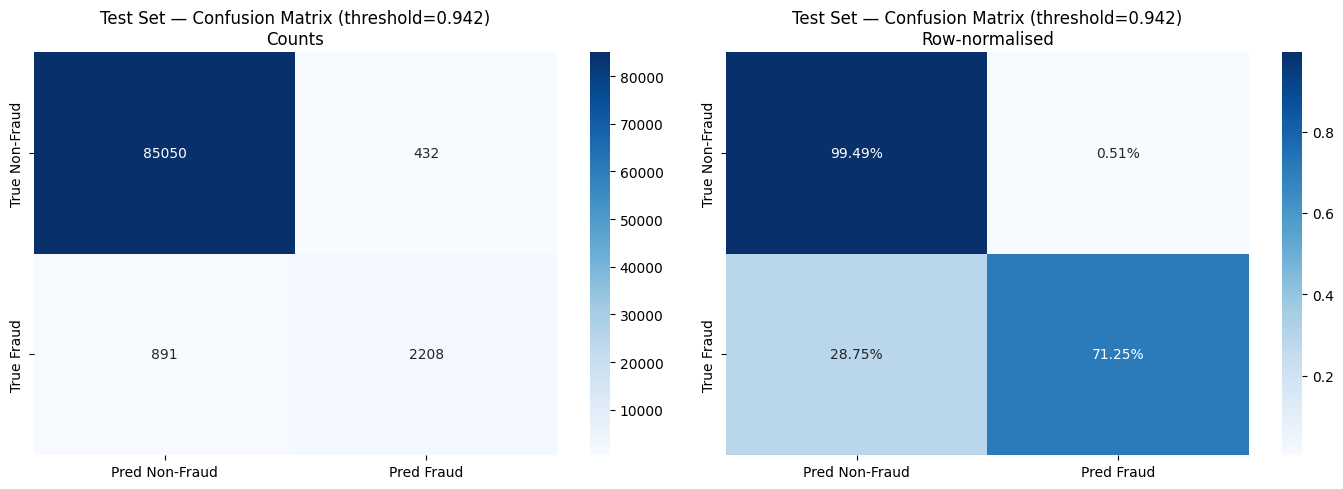


Classification Report (threshold=0.942):
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.84      0.71      0.77      3099

    accuracy                           0.99     88581
   macro avg       0.91      0.85      0.88     88581
weighted avg       0.98      0.99      0.98     88581

Confusion matrix saved to Model_outputs\Model_2\confusion_matrix.png


In [13]:
plot_confusion_matrix(y_true, y_proba, threshold=best_thresh, save_dir=RUN_DIR)

## 11. Save Model

In [14]:
model_path = os.path.join(RUN_DIR, 'Model_2.pt')
torch.save({
    'model_state_dict' : best_state,
    'run_name'         : RUN_NAME,
    'val_pr_auc'       : val_pr,
    'test_pr_auc'      : test_pr,
    'best_thresh'      : best_thresh,
    'test_recall'      : test_recall,
    'val_recall'       : val_recall,
    'cat_cols'         : cat_cols,
    'num_cols'         : num_cols,
    'vocab_sizes'      : vocab_sizes,
}, model_path)
print(f"Model saved to {model_path}")

print(f"\n{'='*50}")
print(f"  All outputs saved to: {RUN_DIR}/")
print(f"    dnn_training_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    training_log.csv")
print(f"    final_metrics.json")
print(f"    dnn_model.pt")
print(f"{'='*50}")

Model saved to Model_outputs\Model_2\Model_2.pt

  All outputs saved to: Model_outputs\Model_2/
    dnn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    final_metrics.json
    dnn_model.pt
